# Лабораторная работа E13 — Снятие своего ЭМГ: электрод, кожа, проверка сигнала

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/biomenace/digital-signal-processing/blob/main/notebooks/e13.ipynb)

Ноутбук-спутник к интерактивной работе: **[открыть саму лабораторную](https://biomenace.github.io/digital-signal-processing/labs/e13.html)**.

**Что разбираем.** До сих пор мы работали с чужой записью. Теперь вопрос
другой: как понять, что **свой** сигнал снят правильно? Глазами это почти не
определить — шумоподобная «трава» на экране выглядит одинаково и при
идеальном контакте, и при отклеившемся электроде. Значит, нужны числа.

Три проверки, которые делают перед любой записью:

* **RMS в покое и в сокращении** — во сколько раз сигнал вырастает при
  напряжении мышцы. Разница меньше нескольких раз означает, что электрод
  стоит не над брюшком мышцы;
* **SNR** — та же разница в децибелах: $20\lg(RMS_{сокр}/RMS_{покой})$;
* **доля энергии в полосе 20–450 Гц** — где именно живёт сигнал. У чистого
  ЭМГ там почти всё; если доля упала, в записи преобладает не мышца, а
  наводка и дрейф.

**Честно про источник.** Настоящего датчика в ноутбуке нет, поэтому «своя»
запись синтезируется — модель в ячейке 2. Проверки от этого не меняются: те
же три числа считают и на реальном MyoWare, подключённом к плате. Меняется
ровно одна строка — откуда берётся массив отсчётов.

In [1]:
# ЯЧЕЙКА 1 · Установка и импорты.
# Запусти один раз в начале работы и больше сюда не возвращайся.
# В Google Colab почти всё уже стоит, поэтому обычно ничего не скачивается.

import importlib.util
import subprocess
import sys


def ensure(packages):
    """Ставит только те пакеты, которых нет. packages: [(модуль, имя-для-pip)]."""
    missing = [pip for mod, pip in packages if not importlib.util.find_spec(mod)]
    if missing:
        print("Ставлю:", ", ".join(missing))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing],
                       check=True)
    print("Готово. Python", sys.version.split()[0])


ensure([("numpy", "numpy"), ("scipy", "scipy"), ("matplotlib", "matplotlib")])

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline
matplotlib.rcParams.update({
    "figure.figsize": (11, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.linewidth": 0.4,
    "axes.titlesize": 12,
    "font.size": 11,
})

Готово. Python 3.10.12


In [2]:
# ЯЧЕЙКА · Свой сигнал: имитация сенсора, которого нет.
# Честно: настоящего ЭМГ-датчика у нас в ноутбуке нет, поэтому «свою» запись
# мы синтезируем. Модель простая и физически осмысленная: ЭМГ — это шум,
# профильтрованный в полосу 20–450 Гц, амплитуда которого следует за усилием
# мышцы. Сюда же добавляются болезни реального тракта: наводка 50 Гц, дрейф
# нуля и постоянное смещение. Когда появится железо, меняется только источник
# сигнала — вся остальная обработка остаётся той же.

from scipy.signal import butter, filtfilt, iirnotch

FS = 1000.0                  # частота дискретизации, Гц
BAND = (20.0, 450.0)         # рабочая полоса ЭМГ


def bandpass(x, fs=FS, lo=BAND[0], hi=BAND[1], order=4):
    """Полосовой фильтр Баттерворта: пропускает только полосу ЭМГ."""
    nyquist = fs / 2.0
    b, a = butter(order, [lo / nyquist, min(hi, nyquist * 0.99) / nyquist],
                  btype="band")
    return filtfilt(b, a, x)


def notch(x, fs=FS, f0=50.0, q=30.0):
    """Режекторный фильтр: вырезает узкую полосу вокруг f0 (сетевая наводка)."""
    b, a = iirnotch(f0 / (fs / 2.0), q)
    return filtfilt(b, a, x)


def rms(x):
    """Эффективная амплитуда сигнала (постоянная составляющая не учитывается)."""
    x = np.asarray(x, float)
    return float(np.sqrt(np.mean((x - np.mean(x)) ** 2)))


def spectrum(x, fs=FS):
    """Амплитудный спектр окна: (частоты, амплитуды)."""
    x = np.asarray(x, float) - np.mean(x)
    return (np.fft.rfftfreq(len(x), d=1.0 / fs),
            np.abs(np.fft.rfft(x * np.hanning(len(x)))))


def power_fraction(x, band, fs=FS):
    """Какая доля энергии сигнала лежит в полосе band = (низ, верх), в герцах."""
    freqs, amplitude = spectrum(x, fs)
    power = amplitude ** 2
    inside = (freqs >= band[0]) & (freqs <= band[1])
    return float(np.sum(power[inside]) / (np.sum(power) + 1e-24))


def band_fraction(x, fs=FS, band=BAND):
    """Доля энергии в рабочей полосе ЭМГ. У чистого сигнала с мышцы — почти вся."""
    return power_fraction(x, band, fs)


def blocks(pattern, seconds):
    """Сценарий усилия из блоков равной длины: [0, 1, 0, 0.6] → покой, сжатие, ..."""
    span = seconds / len(pattern)

    def level(t):
        return pattern[min(len(pattern) - 1, int(t / span))]

    return level


def synth_emg(level_fn, seconds, fs=FS, seed=0, rest=0.05,
              mains=0.0, drift=0.0, offset=0.0, ramp_ms=150.0):
    """«Записать» свой сигнал. Возвращает (x[N], усилие мышцы[N]).

    level_fn(t) задаёт усилие от 0 до 1 в момент t (секунды). Скачки усилия
    сглаживаются за ramp_ms — мышца не включается мгновенно, и вторым значением
    возвращается именно сглаженное усилие: то, что мышца делала на самом деле.
    rest — остаточная активность в покое, mains/drift/offset — грязь тракта в
    тех же единицах.
    """
    rng = np.random.default_rng(seed)
    n = int(seconds * fs)
    t = np.arange(n) / fs

    shaped = bandpass(rng.standard_normal(n), fs)
    shaped /= np.sqrt(np.mean(shaped ** 2)) + 1e-12

    level = np.array([float(level_fn(v)) for v in t])
    width = max(1, int(ramp_ms / 1000.0 * fs))
    kernel = np.hanning(width)
    envelope = np.convolve(level, kernel / kernel.sum(), mode="same")

    x = shaped * (rest + envelope)
    x = x + mains * np.sin(2 * np.pi * 50.0 * t)
    x = x + drift * np.sin(2 * np.pi * 0.7 * t) + offset
    return x, envelope


def add_artifacts(x, mask=None, fs=FS, count=6, amplitude=0.8, ms=60.0, seed=0,
                  gap_ms=500.0):
    """Короткие всплески: подёргивание мышцы, шевеление электрода, толчок кабеля.

    mask — где всплески разрешены (булев массив длины x), gap_ms — минимальный
    промежуток между соседними всплесками, чтобы они не слипались в один.
    Возвращает (сигнал с всплесками, позиции всплесков в отсчётах).
    """
    rng = np.random.default_rng(seed)
    width = int(ms / 1000.0 * fs)
    gap = int(gap_ms / 1000.0 * fs)
    allowed = np.arange(len(x) - width) if mask is None \
        else np.flatnonzero(mask[:len(x) - width])
    if len(allowed) == 0 or count == 0:
        return np.array(x, float), np.array([], int)

    positions = []
    for start in rng.permutation(allowed):
        if all(abs(int(start) - p) >= gap for p in positions):
            positions.append(int(start))
        if len(positions) == count:
            break

    out = np.array(x, float)
    burst = bandpass(rng.standard_normal(width), fs) * np.hanning(width)
    burst = burst / (np.sqrt(np.mean(burst ** 2)) + 1e-12) * amplitude
    for start in positions:
        out[start:start + width] += burst
    return out, np.sort(np.array(positions, int))

In [3]:
# ЯЧЕЙКА 3 · Данные: скачиваем настоящий датасет.
# Работаем не на выдумке, а на открытой записи UCI «EMG Data for Gestures»
# (Lobov et al., 2018): 36 человек, браслет MYO — восемь электродов по
# окружности предплечья, по две серии на человека, размеченные жесты.
# Архив ~17 МБ, качается один раз за сессию. Ничего ставить руками не нужно.

import os
import glob
import urllib.request
import zipfile

DATA_URL = "https://archive.ics.uci.edu/static/public/481/emg+data+for+gestures.zip"
DATA_DIR = "EMG_data_for_gestures-master"

GESTURE_NAMES = {
    0: "неразмечено", 1: "покой", 2: "кулак", 3: "сгибание",
    4: "разгибание", 5: "радиальное", 6: "локтевое", 7: "ладонь",
}


def fetch_dataset(url=DATA_URL, directory=DATA_DIR):
    """Скачивает и распаковывает датасет. Повторный вызов ничего не делает."""
    # Печатаем только имя папки, без полного пути: путь на чужой машине
    # читателю ничего не говорит, а в сохранённом выводе ноутбука остаётся.
    directory = os.environ.get("EMG_DATA_DIR", directory)
    name = os.path.basename(directory.rstrip("/\\")) or directory
    if os.path.isdir(directory):
        print("Датасет уже на месте:", name)
        return directory
    print("Скачиваю архив (~17 МБ)...")
    archive, _ = urllib.request.urlretrieve(url)
    with zipfile.ZipFile(archive) as zf:
        zf.extractall(".")
    os.remove(archive)
    print("Готово:", name)
    return directory


def list_subjects(directory=DATA_DIR):
    """Номера доступных испытуемых: '01', '02', ... '36'."""
    return sorted(d for d in os.listdir(directory)
                  if d.isdigit() and os.path.isdir(os.path.join(directory, d)))


def subject_files(subject, directory=DATA_DIR):
    """Файлы одного человека — обычно две серии, записанные подряд."""
    pattern = os.path.join(directory, str(subject).zfill(2), "*_raw_data_*.txt")
    return sorted(glob.glob(pattern))


def load_record(path):
    """Один файл записи → (X[N, 8], y[N]).

    В файле десять столбцов: время в мс, восемь каналов и метка жеста.
    Шаг времени 1 мс, отсюда FS = 1000 Гц. Метка 0 — участок без разметки.
    Каналы переводим из вольт в милливольты, иначе все числа выглядят как
    0.00002 и читать их невозможно.
    """
    data = np.loadtxt(path, skiprows=1)
    return data[:, 1:9] * 1000.0, data[:, 9].astype(int)


def plot_record(X, y, fs=FS, seconds=12.0, channels=(0, 2, 4, 6)):
    """Кусок записи: как выглядят каналы и где какой жест был размечен."""
    n = min(len(X), int(seconds * fs))
    t = np.arange(n) / fs
    present = sorted(set(int(v) for v in np.unique(y[:n])))
    fig, axes = plt.subplots(len(channels) + 1, 1, sharex=True,
                             figsize=(12, 1.4 * len(channels) + 2.4))
    for ax, c in zip(axes, channels):
        ax.plot(t, X[:n, c], lw=0.6, color="steelblue")
        ax.set_ylabel("кан. %d" % (c + 1))
    axes[-1].step(t, y[:n], where="post", color="darkorange", lw=1.6)
    axes[-1].set(xlabel="$t$, с", ylabel="жест", yticks=present)
    axes[-1].set_yticklabels([GESTURE_NAMES[v] for v in present])
    axes[0].set_title("Запись браслета MYO: четыре канала из восьми и разметка жестов")
    fig.tight_layout()
    plt.show()


def class_table(y, title="Распределение по классам"):
    """Сколько окон (или отсчётов) пришлось на каждый класс."""
    values, counts = np.unique(y, return_counts=True)
    print(title + ":")
    for v, c in zip(values, counts):
        print("   %-12s %6d" % (GESTURE_NAMES[int(v)], c))

## Ячейка 4 · «Записываем» свой сигнал

Сценарий обычной проверочной записи: несколько секунд полного покоя, затем
несколько секунд удержания сжатия. Именно так снимают первую запись после
наклейки электродов.

In [4]:
SECONDS = 8.0
PATTERN = [0.0, 1.0]            # первая половина — покой, вторая — сокращение

own, own_level = synth_emg(blocks(PATTERN, SECONDS), SECONDS, seed=3)
half = len(own) // 2
own_rest, own_contract = own[:half], own[half:]

print("Записано %.0f с при %.0f Гц — %d отсчётов." % (SECONDS, FS, len(own)))
print("RMS покоя      = %.4f" % rms(own_rest))
print("RMS сокращения = %.4f" % rms(own_contract))
print("Отношение      = %.1f раза" % (rms(own_contract) / (rms(own_rest) + 1e-12)))

Записано 8 с при 1000 Гц — 8000 отсчётов.
RMS покоя      = 0.0581
RMS сокращения = 1.0393
Отношение      = 17.9 раза


## Ячейка 5 · Те же числа на настоящей записи

Сравнивать нужно не с идеалом из головы, а с реальными данными. Берём из
датасета UCI одно окно покоя и одно окно сжатого кулака — по первому каналу,
как если бы у нас был один электрод.

In [5]:
WINDOW_MS = 256.0

root = fetch_dataset()
X, y = load_record(subject_files("01", root)[0])
width = int(WINDOW_MS / 1000.0 * FS)


def middle_window(signal, labels, gesture, w):
    """Окно длиной w отсчётов из середины участка с нужным жестом."""
    index = np.flatnonzero(labels == gesture)
    centre = index[len(index) // 2]
    start = min(max(0, centre - w // 2), len(signal) - w)
    return signal[start:start + w, 0]


real_rest = middle_window(X, y, 1, width)          # покой
real_contract = middle_window(X, y, 2, width)      # кулак


def report(name, rest_window, contract_window, fs=FS):
    """Три числа проверки: SNR и доля энергии в рабочей полосе для обоих окон."""
    snr = 20.0 * np.log10((rms(contract_window) + 1e-12) / (rms(rest_window) + 1e-12))
    print("%-22s SNR = %5.1f дБ | в полосе %d–%d Гц: покой %3.0f %%, сокращение %3.0f %%"
          % (name, snr, BAND[0], BAND[1],
             100 * band_fraction(rest_window, fs),
             100 * band_fraction(contract_window, fs)))


print("Единицы у своей записи и у датасета разные (у датасета — мВ),")
print("поэтому сравниваем безразмерное: отношение амплитуд и полосу.\n")
report("своя запись:", own_rest[-width:], own_contract[-width:])
report("датасет (канал 1):", real_rest, real_contract)
print("\nНиже 20 Гц: своя запись %2.0f %%, датасет %2.0f %%."
      % (100 * power_fraction(own_contract[-width:], (0.0, 20.0)),
         100 * power_fraction(real_contract, (0.0, 20.0))))

Датасет уже на месте: EMG_data_for_gestures-master
Единицы у своей записи и у датасета разные (у датасета — мВ),
поэтому сравниваем безразмерное: отношение амплитуд и полосу.

своя запись:           SNR =  17.7 дБ | в полосе 20–450 Гц: покой  99 %, сокращение  99 %
датасет (канал 1):     SNR =  22.4 дБ | в полосе 20–450 Гц: покой  51 %, сокращение  40 %

Ниже 20 Гц: своя запись  1 %, датасет 59 %.


## Ячейка 6 · Смотрим на оба сигнала и на оба спектра

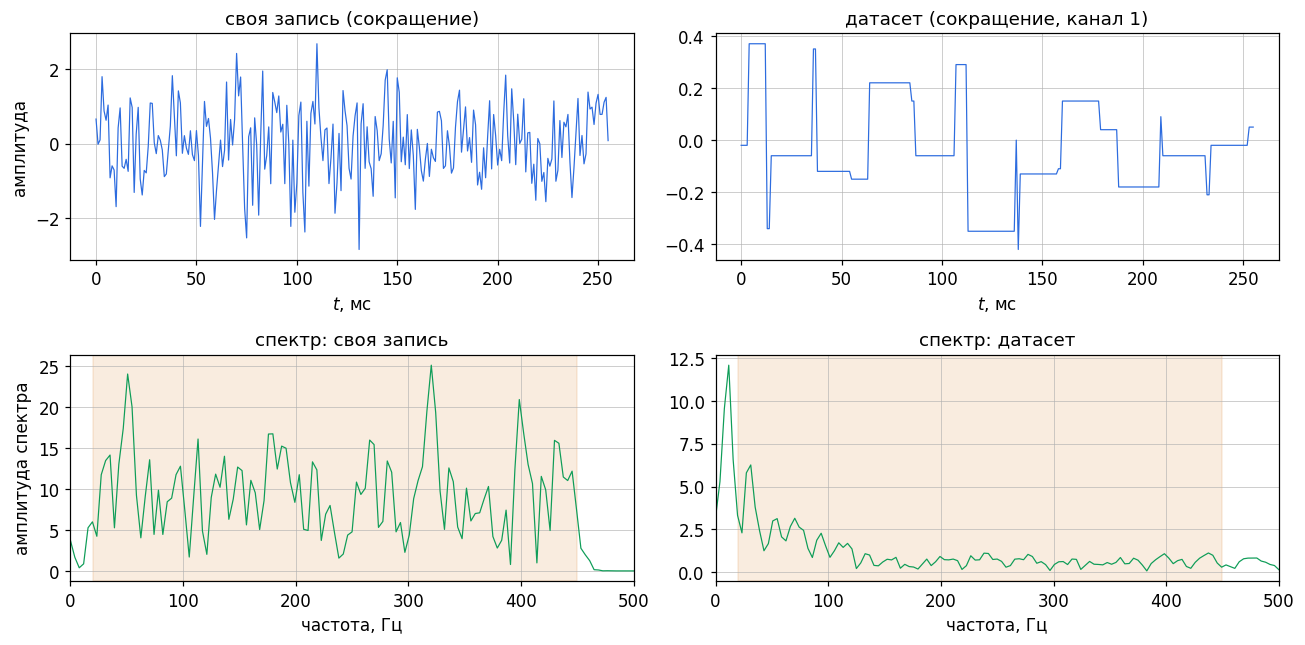

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6.0))

for column, (signal, title) in enumerate([
        (own_contract[-width:], "своя запись (сокращение)"),
        (real_contract, "датасет (сокращение, канал 1)")]):
    time = np.arange(len(signal)) / FS * 1000.0
    axes[0, column].plot(time, signal, lw=0.8, color="#2d6cdf")
    axes[0, column].set(title=title, xlabel="$t$, мс")

    freqs, amplitude = spectrum(signal, FS)
    axes[1, column].plot(freqs, amplitude, lw=0.8, color="#0f9d58")
    axes[1, column].axvspan(BAND[0], BAND[1], color="#d9822b", alpha=0.15)
    axes[1, column].set(title="спектр: " + title.split(" (")[0],
                        xlabel="частота, Гц", xlim=(0, 500))

axes[0, 0].set_ylabel("амплитуда")
axes[1, 0].set_ylabel("амплитуда спектра")
fig.tight_layout()
plt.show()

Абсолютные высоты разные — шкалы датчиков разные, и это нормально. Общее у
них главное: обе записи шумоподобные, ни у одной нет острого пика на одной
частоте, и амплитуда обеих растёт при напряжении мышцы. Так выглядит сигнал,
снятый действительно с мышцы.

Расходятся они в другом: у записи браслета заметная часть энергии лежит
**ниже 20 Гц**, чего у лабораторного ЭМГ быть не должно. Посмотри на верхний
правый график — сигнал идёт ступеньками. В файле шаг времени 1 мс, но само
значение меняется примерно раз в 9 мс: браслет отдаёт данные примерно сто раз
в секунду, а в записи каждое значение просто повторено. Реальная частота
дискретизации здесь ~100 Гц, а не 1000, и по теореме Найквиста (лаба E1)
ничего выше ~50 Гц в этой записи и не может быть.

Отсюда правило: «доля энергии в полосе» сравнивается со своим же датчиком в
хорошем состоянии, а не с чужим прибором.

## Ячейка 7 · А теперь плохой контакт

Электрод отклеился, гель высох, кабель болтается — тракт начинает ловить
сеть 50 Гц и медленно плыть нулём. Амплитуда при этом может даже вырасти, и
на глаз запись выглядит «живее». Ловить такое надо **узкими** проверками:
сколько энергии сидит вокруг 50 Гц и сколько ниже 20 Гц.

RMS: хороший контакт 1.0393, плохой 1.0830 — по амплитуде их не отличить.

Энергия вокруг 50 Гц (сеть):
   хороший контакт:  1.1 %
   плохой контакт:   6.1 %
Энергия ниже 20 Гц (дрейф нуля):
   хороший контакт:  0.1 %
   плохой контакт:   3.8 %

А широкая проверка «доля в полосе 20–450 Гц» даёт 100 % против 96 % —
почти одно и то же: 50 Гц лежит внутри рабочей полосы. Нужны узкие.


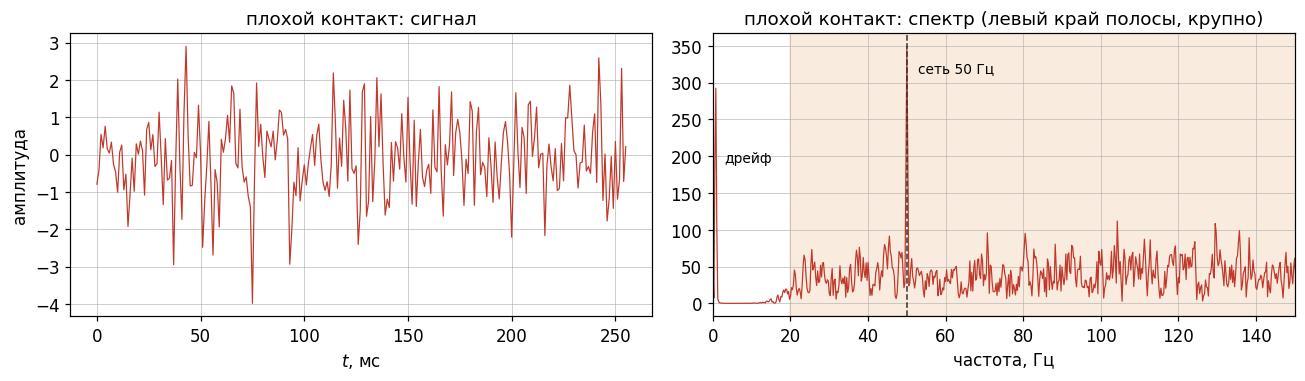

In [7]:
bad, _ = synth_emg(blocks(PATTERN, SECONDS), SECONDS, seed=3,
                   mains=0.35,      # наводка от сети
                   drift=0.30,      # дрейф нуля: пот, движение электрода
                   offset=0.10)     # смещение нуля
# Здесь берём всю секцию сокращения, а не одно короткое окно: узкую наводку
# видно только при хорошем разрешении по частоте, а оно растёт с длиной куска.
bad_contract = bad[half:]
good_contract = own_contract

print("RMS: хороший контакт %.4f, плохой %.4f — по амплитуде их не отличить."
      % (rms(good_contract), rms(bad_contract)))
print("\nЭнергия вокруг 50 Гц (сеть):")
print("   хороший контакт: %4.1f %%" % (100 * power_fraction(good_contract, (48.0, 52.0))))
print("   плохой контакт:  %4.1f %%" % (100 * power_fraction(bad_contract, (48.0, 52.0))))
print("Энергия ниже 20 Гц (дрейф нуля):")
print("   хороший контакт: %4.1f %%" % (100 * power_fraction(good_contract, (0.0, 20.0))))
print("   плохой контакт:  %4.1f %%" % (100 * power_fraction(bad_contract, (0.0, 20.0))))
print("\nА широкая проверка «доля в полосе %d–%d Гц» даёт %2.0f %% против %2.0f %% —"
      % (BAND[0], BAND[1], 100 * band_fraction(good_contract),
         100 * band_fraction(bad_contract)))
print("почти одно и то же: 50 Гц лежит внутри рабочей полосы. Нужны узкие.")

fig, (left, right) = plt.subplots(1, 2, figsize=(12, 3.6))
time = np.arange(width) / FS * 1000.0
left.plot(time, bad_contract[:width], lw=0.8, color="#c0392b")
left.set(title="плохой контакт: сигнал", xlabel="$t$, мс", ylabel="амплитуда")

freqs, amplitude = spectrum(bad_contract, FS)
right.plot(freqs, amplitude, lw=0.8, color="#c0392b")
right.axvspan(BAND[0], BAND[1], color="#d9822b", alpha=0.15)
right.axvline(50.0, color="#333", ls="--", lw=1.0)
right.text(53, amplitude.max() * 0.9, "сеть 50 Гц", fontsize=9)
right.text(3, amplitude.max() * 0.55, "дрейф", fontsize=9)
right.set(title="плохой контакт: спектр (левый край полосы, крупно)",
          xlabel="частота, Гц", xlim=(0, 150))
fig.tight_layout()
plt.show()

Пик на 50 Гц и подъём у нуля — подпись сети и дрейфа. Их можно убрать
фильтрами (этим займётся E14), но лучше сначала исправить контакт: фильтр
вырезает помеху вместе с куском полезной полосы.

## Задания

1. Приведи для своей записи три числа: RMS покоя, RMS сокращения и SNR в дБ.
   Сравни с датасетом и объясни, почему абсолютные значения не совпадают, а
   отношение — да.
2. Прогони `mains` = 0, 0.1, 0.35, 1.0 при неизменном сигнале и построй
   зависимость доли энергии вокруг 50 Гц от уровня наводки. С какого уровня
   запись уже нельзя считать пригодной? Почему широкая проверка «доля в
   полосе 20–450 Гц» этого не показывает?
3. Возьми из датасета окна для всех семи жестов и посчитай для каждого SNR
   относительно покоя. Какие жесты дают самый слабый сигнал на первом канале
   и почему это зависит от того, где стоит электрод?